In [42]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score, ConfusionMatrixDisplay

In [2]:
df=pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.info

<bound method DataFrame.info of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no

In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [6]:
from sklearn.preprocessing import LabelEncoder

le= LabelEncoder()
cols=['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in cols:
    df[col]=le.fit_transform(df[col])

In [7]:
from sklearn.preprocessing import OrdinalEncoder

oe=OrdinalEncoder(categories=[['furnished','semi-furnished','unfurnished']])
df[['furnishingstatus']]=oe.fit_transform(df[['furnishingstatus']])

In [8]:
x=df.drop('price',axis=1)
y=df.price

print(x.shape)
print(y.shape)


(545, 12)
(545,)


In [9]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1.0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0.0


<Axes: >

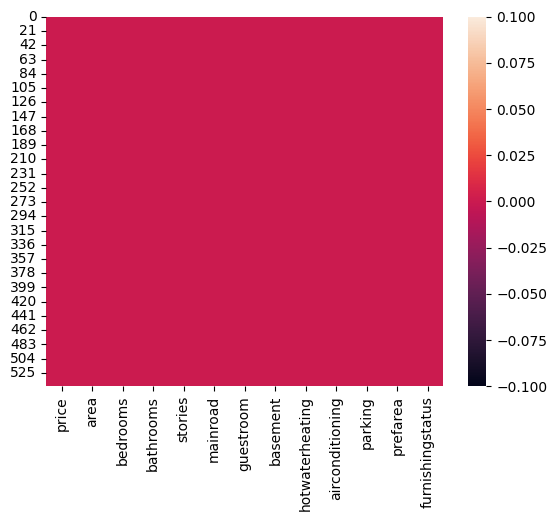

In [10]:
sn.heatmap(df.isnull())

<Axes: xlabel='price', ylabel='Count'>

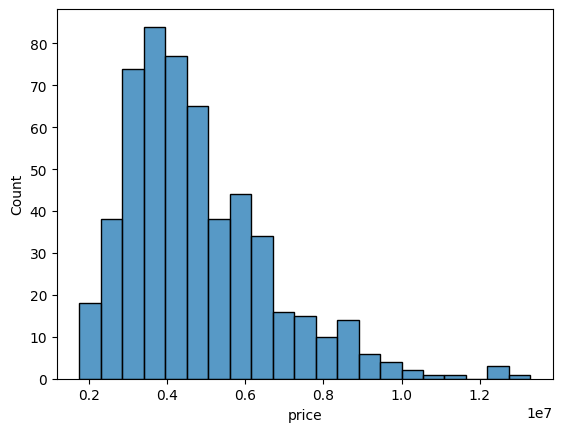

In [11]:
sn.histplot(df['price'])

<Axes: xlabel='price'>

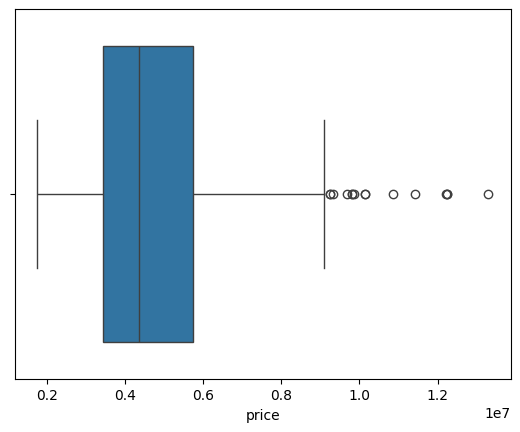

In [15]:
sn.boxplot(df.price,orient="h")

In [30]:
q1=df['price'].quantile(0.25)
q3=df['price'].quantile(0.75)
IQR=q3-q1

outliers= df[(df['price'])>q3+IRQ]
print(f"Total outliers = {len(outliers)}")




Total outliers = 2


In [31]:
# removing outliers
lower=q1-IQR
upper=q3+IQR

df=df[(df['price']>=lower) & (df['price']<=upper)]

<Axes: ylabel='price'>

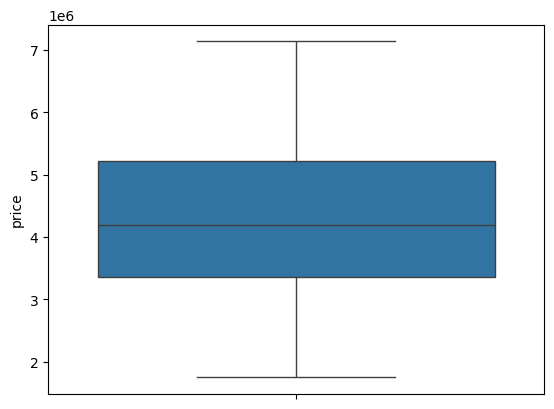

In [32]:
sn.boxplot(df['price'])

In [34]:
x=df.drop('price',axis=1)
y=df.price

In [38]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
xnew=scaler.fit_transform(x)

In [39]:
xtrain,xtest,ytrain,ytest=train_test_split(xnew,y,test_size=0.2,random_state=42)

In [46]:
model=LinearRegression()
model.fit(xtrain,ytrain)

predict=model.predict(xtest)
mae=mean_absolute_error(ytest,predict)
r2=r2_score(ytest,predict)
print(f'Mean Absolute Error={mae:,.2f}')
print(f'R2 score={r2:,.4f}')

Mean Absolute Error=646,929.33
R2 score=0.6370


In [ ]:
import pickle

with open( "housing_model.pkl",'wb') as f:
    pickle.dump(model,f)

with open ("housing_scaler.pkl",'wb') as f:
    pickle.dump(scaler,f)